# Synthetic Retail Demand Forecast and Scenario Outputs

This notebook creates forecast and scenario outputs for the **Synthetic Retail Demand & Forecasting Analytics Dashboard**.

The purpose is not to build a complex forecasting model. The purpose is to create a practical, business-facing forecast dataset that can support Power BI analysis of:

- baseline demand
- event-adjusted demand
- holiday and reduced-trading effects
- store and product differences
- operational risk periods

The final output is designed for Power BI, with business-friendly columns and without exposing technical generation multipliers in the dashboard dataset.


## 1. Import libraries and set forecast parameters

The forecast period is controlled by two parameters:

- `FORECAST_START_DATE`
- `FORECAST_DAYS`

The notebook expects the cleaned data-generation notebook to have already created:

- `demand_actuals.csv`
- `stores.csv`
- `products.csv`
- `calendar.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(42)

DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path(".")

FORECAST_START_DATE = "2026-01-01"
FORECAST_DAYS = 180

ASSUMED_MONTHLY_GROWTH_RATE = 0.0025  # approx. 3.0% annualised growth


## 2. Load historical actuals and reference tables

The historical demand data is treated as operational retail data.

The forecast notebook joins actual demand to store and product dimensions so the learning logic can estimate demand patterns by store type and product.


In [2]:
demand_actuals = pd.read_csv(DATA_DIR / "demand_actuals.csv", parse_dates=["date"])
stores = pd.read_csv(DATA_DIR / "stores.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
calendar = pd.read_csv(DATA_DIR / "calendar.csv", parse_dates=["date"])

actuals = (
    demand_actuals
    .merge(stores, on="store_id", how="left")
    .merge(products, on="product_id", how="left")
)

actuals["day_of_week"] = actuals["date"].dt.day_name()
actuals["month"] = actuals["date"].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return "summer"
    if month in [3, 4, 5]:
        return "autumn"
    if month in [6, 7, 8]:
        return "winter"
    return "spring"

actuals["season"] = actuals["month"].apply(get_season)

print("Historical rows:", len(actuals))
print("Date range:", actuals["date"].min().date(), "to", actuals["date"].max().date())
print("Stores:", actuals["store_id"].nunique())
print("Products:", actuals["product_id"].nunique())


Historical rows: 10950
Date range: 2025-01-01 to 2025-12-31
Stores: 3
Products: 10


## 3. Clean known disruption periods for learning demand patterns

Known disruption periods are not removed from the historical dataset. They remain in `demand_actuals.csv` for Power BI analysis.

However, they are cleaned in a modelling copy before learning normal demand patterns. This stops abnormal disruption periods from being mistaken for normal product demand.

For each disrupted product/store/day-of-week combination, the replacement value is estimated from nearby clean days.


In [3]:
actuals["cleaned_units_for_forecast"] = actuals["actual_units"].astype(float)

def clean_disruptions(df, window_days=14):
    df = df.copy()

    disruption_groups = (
        df[df["disruption_flag"] == 1]
        .groupby(["product_id", "disruption_type"])
        .agg(
            disruption_start=("date", "min"),
            disruption_end=("date", "max")
        )
        .reset_index()
    )

    for _, disruption in disruption_groups.iterrows():
        product_id = disruption["product_id"]
        disruption_type = disruption["disruption_type"]
        start = disruption["disruption_start"]
        end = disruption["disruption_end"]

        before_start = start - pd.Timedelta(days=window_days)
        before_end = start - pd.Timedelta(days=1)
        after_start = end + pd.Timedelta(days=1)
        after_end = end + pd.Timedelta(days=window_days)

        disruption_mask = (
            (df["product_id"] == product_id)
            & (df["disruption_type"] == disruption_type)
            & (df["date"] >= start)
            & (df["date"] <= end)
        )

        for idx, disrupted_row in df[disruption_mask].iterrows():
            nearby_same_weekday = df[
                (df["store_id"] == disrupted_row["store_id"])
                & (df["product_id"] == product_id)
                & (df["day_of_week"] == disrupted_row["day_of_week"])
                & (df["disruption_flag"] == 0)
                & (
                    ((df["date"] >= before_start) & (df["date"] <= before_end))
                    |
                    ((df["date"] >= after_start) & (df["date"] <= after_end))
                )
            ]

            replacement_units = nearby_same_weekday["actual_units"].mean()

            if pd.notna(replacement_units):
                df.loc[idx, "cleaned_units_for_forecast"] = replacement_units

    df["cleaned_units_for_forecast"] = (
        df["cleaned_units_for_forecast"]
        .round()
        .astype(int)
    )

    return df

model_data = clean_disruptions(actuals, window_days=14)
model_data["model_units"] = model_data["cleaned_units_for_forecast"]

print("Disrupted rows cleaned for modelling:", int((actuals["disruption_flag"] == 1).sum()))


Disrupted rows cleaned for modelling: 150


## 4. Estimate recent baseline demand

The baseline is estimated from the most recent 90 days of normal trading activity.

Normal trading excludes:

- closures
- holidays/events
- disruption periods

This gives a recent demand level for each store-product pair.


In [4]:
last_historical_date = model_data["date"].max()
baseline_start_date = last_historical_date - pd.Timedelta(days=90)

recent_normal_baseline_data = model_data[
    (model_data["date"] >= baseline_start_date)
    & (model_data["closure_flag"] == 0)
    & (model_data["holiday_flag"] == 0)
    & (model_data["event_window"] == "normal")
    & (model_data["disruption_flag"] == 0)
].copy()

baseline_table = (
    recent_normal_baseline_data
    .groupby(["store_id", "store_type", "product_id"], as_index=False)
    .agg(
        baseline_units=("model_units", "mean"),
        baseline_observations=("model_units", "count")
    )
)

baseline_table["baseline_units"] = baseline_table["baseline_units"].round(2)

print("Baseline rows:", len(baseline_table))
baseline_table.head()


Baseline rows: 30


,store_id,store_type,product_id,baseline_units,baseline_observations
0,S001,metro,P001,618.90,58
1,S001,metro,P002,514.97,58
2,S001,metro,P003,355.98,58
3,S001,metro,P004,213.28,58
4,S001,metro,P005,108.53,58


## 5. Learn normal weekday and monthly demand patterns

These learning tables are used internally to create the forecast output. They are not exported to Power BI as dashboard fields.


In [5]:
model_data = model_data.merge(
    baseline_table[["store_id", "product_id", "baseline_units"]],
    on=["store_id", "product_id"],
    how="left"
)

normal_learning_data = model_data[
    (model_data["closure_flag"] == 0)
    & (model_data["holiday_flag"] == 0)
    & (model_data["event_window"] == "normal")
    & (model_data["disruption_flag"] == 0)
].copy()

normal_learning_data["units_vs_baseline"] = (
    normal_learning_data["model_units"]
    / normal_learning_data["baseline_units"]
)

weekday_multiplier_table = (
    normal_learning_data
    .groupby(["product_id", "day_of_week"], as_index=False)
    .agg(
        weekday_multiplier=("units_vs_baseline", "mean"),
        weekday_observations=("units_vs_baseline", "count")
    )
)

weekday_multiplier_table["weekday_multiplier"] = (
    weekday_multiplier_table["weekday_multiplier"].round(3)
)

season_learning_data = normal_learning_data.merge(
    weekday_multiplier_table[["product_id", "day_of_week", "weekday_multiplier"]],
    on=["product_id", "day_of_week"],
    how="left"
)

season_learning_data["units_after_weekday_adjustment"] = (
    season_learning_data["model_units"]
    / season_learning_data["weekday_multiplier"]
)

season_learning_data["units_vs_baseline_after_weekday"] = (
    season_learning_data["units_after_weekday_adjustment"]
    / season_learning_data["baseline_units"]
)

monthly_multiplier_table = (
    season_learning_data
    .groupby(["product_id", "month", "season"], as_index=False)
    .agg(
        monthly_multiplier=("units_vs_baseline_after_weekday", "mean"),
        seasonal_observations=("units_vs_baseline_after_weekday", "count")
    )
)

monthly_multiplier_table["monthly_multiplier"] = (
    monthly_multiplier_table["monthly_multiplier"].round(3)
)

print("Weekday pattern rows:", len(weekday_multiplier_table))
print("Monthly pattern rows:", len(monthly_multiplier_table))


Weekday pattern rows: 70
Monthly pattern rows: 120


## 6. Learn event and reduced-trading impacts

Event effects are estimated after accounting for baseline demand, weekday patterns and monthly seasonality.

Reduced-trading days are handled separately because they represent a specific operational trading-status effect.


In [6]:
event_learning_data = model_data.merge(
    weekday_multiplier_table[["product_id", "day_of_week", "weekday_multiplier"]],
    on=["product_id", "day_of_week"],
    how="left"
)

event_learning_data = event_learning_data.merge(
    monthly_multiplier_table[["product_id", "month", "season", "monthly_multiplier"]],
    on=["product_id", "month", "season"],
    how="left"
)

reduced_trading_windows = [
    "new_years_day_reduced_trading",
    "easter_monday_reduced_trading"
]

event_learning_data = event_learning_data[
    (event_learning_data["holiday_flag"] == 1)
    & (event_learning_data["event_window"] != "normal")
    & (~event_learning_data["event_window"].isin(reduced_trading_windows))
    & (event_learning_data["closure_flag"] == 0)
    & (event_learning_data["disruption_flag"] == 0)
].copy()

event_learning_data["event_effect_ratio"] = (
    event_learning_data["model_units"]
    / event_learning_data["baseline_units"]
    / event_learning_data["weekday_multiplier"]
    / event_learning_data["monthly_multiplier"]
)

event_multiplier_table = (
    event_learning_data
    .groupby(["store_type", "product_id", "event_window"], as_index=False)
    .agg(
        event_multiplier=("event_effect_ratio", "mean"),
        event_observations=("event_effect_ratio", "count")
    )
)

event_multiplier_table["event_multiplier"] = (
    event_multiplier_table["event_multiplier"].round(3)
)

reduced_trading_data = model_data[
    (model_data["event_window"].isin(reduced_trading_windows))
    & (model_data["closure_flag"] == 0)
    & (model_data["disruption_flag"] == 0)
].copy()

reduced_trading_data = reduced_trading_data.merge(
    weekday_multiplier_table[["product_id", "day_of_week", "weekday_multiplier"]],
    on=["product_id", "day_of_week"],
    how="left"
)

reduced_trading_data = reduced_trading_data.merge(
    monthly_multiplier_table[["product_id", "month", "season", "monthly_multiplier"]],
    on=["product_id", "month", "season"],
    how="left"
)

reduced_trading_data["reduced_trading_ratio"] = (
    reduced_trading_data["model_units"]
    / reduced_trading_data["baseline_units"]
    / reduced_trading_data["weekday_multiplier"]
    / reduced_trading_data["monthly_multiplier"]
)

reduced_trading_multiplier_table = (
    reduced_trading_data
    .groupby(["store_type", "event_window"], as_index=False)
    .agg(
        reduced_trading_multiplier=("reduced_trading_ratio", "mean"),
        reduced_trading_observations=("reduced_trading_ratio", "count")
    )
)

reduced_trading_multiplier_table["reduced_trading_multiplier"] = (
    reduced_trading_multiplier_table["reduced_trading_multiplier"].round(3)
)

print("Event multiplier rows:", len(event_multiplier_table))
print("Reduced-trading multiplier rows:", len(reduced_trading_multiplier_table))


Event multiplier rows: 390
Reduced-trading multiplier rows: 6


## 7. Create structured future event reference table

Future events are stored as structured rules and expanded into a daily event table.

This keeps holiday/event handling maintainable and creates a Power BI-ready `scenario_events.csv` reference table.


In [7]:
future_event_rules = [
    {"start_date": "2026-01-01", "end_date": "2026-01-01", "holiday_name": "New Year", "event_type": "new_year", "trading_status": "reduced_trading", "expected_impact": "reduced trading", "event_window": "new_years_day_reduced_trading"},
    {"start_date": "2026-01-02", "end_date": "2026-01-05", "holiday_name": "New Year", "event_type": "new_year", "trading_status": "normal", "expected_impact": "event-affected demand", "event_window": "new_year_travel_period"},

    {"start_date": "2026-01-23", "end_date": "2026-01-23", "holiday_name": "Australia Day Long Weekend", "event_type": "long_weekend", "trading_status": "normal", "expected_impact": "pre-holiday uplift", "event_window": "pre_long_weekend_stock_up"},
    {"start_date": "2026-01-24", "end_date": "2026-01-26", "holiday_name": "Australia Day Long Weekend", "event_type": "long_weekend", "trading_status": "normal", "expected_impact": "long-weekend demand", "event_window": "long_weekend"},
    {"start_date": "2026-01-27", "end_date": "2026-01-27", "holiday_name": "Australia Day Long Weekend", "event_type": "long_weekend", "trading_status": "normal", "expected_impact": "post-holiday recovery", "event_window": "post_long_weekend"},

    {"start_date": "2026-03-26", "end_date": "2026-04-02", "holiday_name": "Easter", "event_type": "easter", "trading_status": "normal", "expected_impact": "pre-holiday uplift", "event_window": "easter_build_up"},
    {"start_date": "2026-04-03", "end_date": "2026-04-03", "holiday_name": "Good Friday", "event_type": "easter", "trading_status": "closed", "expected_impact": "closed trading day", "event_window": "good_friday_closed"},
    {"start_date": "2026-04-04", "end_date": "2026-04-04", "holiday_name": "Easter", "event_type": "easter", "trading_status": "normal", "expected_impact": "long-weekend demand", "event_window": "easter_long_weekend"},
    {"start_date": "2026-04-05", "end_date": "2026-04-05", "holiday_name": "Easter Sunday", "event_type": "easter", "trading_status": "closed", "expected_impact": "closed trading day", "event_window": "easter_sunday_closed"},
    {"start_date": "2026-04-06", "end_date": "2026-04-06", "holiday_name": "Easter Monday", "event_type": "easter", "trading_status": "reduced_trading", "expected_impact": "reduced trading", "event_window": "easter_monday_reduced_trading"},
    {"start_date": "2026-04-07", "end_date": "2026-04-10", "holiday_name": "Easter", "event_type": "easter", "trading_status": "normal", "expected_impact": "post-holiday recovery", "event_window": "post_easter_normalisation"},

    {"start_date": "2026-04-25", "end_date": "2026-04-25", "holiday_name": "ANZAC Day", "event_type": "public_holiday", "trading_status": "closed", "expected_impact": "closed trading day", "event_window": "anzac_day_closed"},
    {"start_date": "2026-04-27", "end_date": "2026-04-27", "holiday_name": "ANZAC Day Additional Public Holiday", "event_type": "public_holiday", "trading_status": "normal", "expected_impact": "public-holiday demand", "event_window": "anzac_additional_public_holiday"},

    {"start_date": "2026-06-05", "end_date": "2026-06-05", "holiday_name": "King's Birthday Long Weekend", "event_type": "long_weekend", "trading_status": "normal", "expected_impact": "pre-holiday uplift", "event_window": "pre_long_weekend_stock_up"},
    {"start_date": "2026-06-06", "end_date": "2026-06-08", "holiday_name": "King's Birthday Long Weekend", "event_type": "long_weekend", "trading_status": "normal", "expected_impact": "long-weekend demand", "event_window": "long_weekend"},
    {"start_date": "2026-06-09", "end_date": "2026-06-09", "holiday_name": "King's Birthday Long Weekend", "event_type": "long_weekend", "trading_status": "normal", "expected_impact": "post-holiday recovery", "event_window": "post_long_weekend"},
]

def build_event_table(start_date, end_date, event_rules):
    events = pd.DataFrame({
        "date": pd.date_range(start_date, end_date, freq="D")
    })

    events["holiday_name"] = "None"
    events["event_type"] = "none"
    events["trading_status"] = "normal"
    events["expected_impact"] = "normal demand"
    events["event_window"] = "normal"

    for rule in event_rules:
        event_mask = events["date"].between(
            pd.Timestamp(rule["start_date"]),
            pd.Timestamp(rule["end_date"])
        )

        for column in [
            "holiday_name",
            "event_type",
            "trading_status",
            "expected_impact",
            "event_window"
        ]:
            events.loc[event_mask, column] = rule[column]

    events["holiday_flag"] = (events["event_type"] != "none").astype(int)
    events["closure_flag"] = (events["trading_status"] == "closed").astype(int)
    events["reduced_trading_flag"] = (events["trading_status"] == "reduced_trading").astype(int)
    events["disruption_flag"] = 0

    return events


## 8. Build the future calendar

The future calendar creates one row per forecast date and joins the future event reference table.


In [8]:
forecast_start_date = pd.Timestamp(FORECAST_START_DATE)
forecast_end_date = forecast_start_date + pd.Timedelta(days=FORECAST_DAYS - 1)

future_calendar = pd.DataFrame({
    "date": pd.date_range(forecast_start_date, forecast_end_date, freq="D")
})

future_calendar["year"] = future_calendar["date"].dt.year
future_calendar["quarter"] = future_calendar["date"].dt.quarter
future_calendar["month"] = future_calendar["date"].dt.month
future_calendar["month_name"] = future_calendar["date"].dt.month_name()
future_calendar["week"] = future_calendar["date"].dt.isocalendar().week.astype(int)
future_calendar["day_of_week"] = future_calendar["date"].dt.day_name()
future_calendar["day_of_week_number"] = future_calendar["date"].dt.dayofweek + 1
future_calendar["is_weekend"] = future_calendar["date"].dt.dayofweek.isin([5, 6]).astype(int)
future_calendar["season"] = future_calendar["month"].apply(get_season)

scenario_events = build_event_table(
    forecast_start_date,
    forecast_end_date,
    future_event_rules
)

future_calendar = future_calendar.merge(
    scenario_events[
        [
            "date",
            "holiday_flag",
            "holiday_name",
            "event_type",
            "trading_status",
            "expected_impact",
            "event_window",
            "closure_flag",
            "reduced_trading_flag",
            "disruption_flag"
        ]
    ],
    on="date",
    how="left"
)

print("Forecast start:", forecast_start_date.date())
print("Forecast end:", forecast_end_date.date())
print("Forecast days:", len(future_calendar))


Forecast start: 2026-01-01
Forecast end: 2026-06-29
Forecast days: 180


## 9. Build the forecast matrix

The forecast matrix creates one row for each:

`forecast date × store × product`

This is the same grain that Power BI will use for forecast analysis.


In [9]:
store_product_base = baseline_table[
    ["store_id", "store_type", "product_id", "baseline_units"]
].copy()

forecast_matrix = future_calendar.merge(
    store_product_base,
    how="cross"
)

forecast_matrix = forecast_matrix.merge(
    weekday_multiplier_table[["product_id", "day_of_week", "weekday_multiplier"]],
    on=["product_id", "day_of_week"],
    how="left"
)

forecast_matrix = forecast_matrix.merge(
    monthly_multiplier_table[["product_id", "month", "season", "monthly_multiplier"]],
    on=["product_id", "month", "season"],
    how="left"
)

forecast_matrix = forecast_matrix.merge(
    event_multiplier_table[["store_type", "product_id", "event_window", "event_multiplier"]],
    on=["store_type", "product_id", "event_window"],
    how="left"
)

forecast_matrix["event_multiplier"] = forecast_matrix["event_multiplier"].fillna(1.00)

forecast_matrix = forecast_matrix.merge(
    reduced_trading_multiplier_table[["store_type", "event_window", "reduced_trading_multiplier"]],
    on=["store_type", "event_window"],
    how="left"
)

forecast_matrix["reduced_trading_multiplier"] = (
    forecast_matrix["reduced_trading_multiplier"].fillna(1.00)
)

print("Forecast matrix rows:", len(forecast_matrix))


Forecast matrix rows: 5400


## 10. Calculate baseline and scenario forecasts

Two business-facing forecast values are created:

- `baseline_forecast_units`: expected demand under normal calendar behaviour
- `scenario_forecast_units`: event-adjusted demand after holidays, closures and reduced-trading effects

A small amount of random variation is added to the scenario forecast so the future pattern behaves more like realistic retail demand. The technical noise field is not exported to Power BI.


In [10]:
forecast_matrix["months_after_history"] = (
    (forecast_matrix["date"].dt.year - last_historical_date.year) * 12
    + (forecast_matrix["date"].dt.month - last_historical_date.month)
)

forecast_matrix["business_growth_factor"] = (
    1 + forecast_matrix["months_after_history"] * ASSUMED_MONTHLY_GROWTH_RATE
)

forecast_matrix["baseline_forecast_units"] = (
    forecast_matrix["baseline_units"]
    * forecast_matrix["weekday_multiplier"]
    * forecast_matrix["monthly_multiplier"]
    * forecast_matrix["business_growth_factor"]
)

forecast_matrix["scenario_forecast_units"] = (
    forecast_matrix["baseline_forecast_units"]
    * forecast_matrix["event_multiplier"]
    * forecast_matrix["reduced_trading_multiplier"]
)

forecast_matrix.loc[
    forecast_matrix["closure_flag"] == 1,
    "scenario_forecast_units"
] = 0

# Estimate normal unexplained variation from historical normal trading days.
noise_learning_data = normal_learning_data.merge(
    weekday_multiplier_table[["product_id", "day_of_week", "weekday_multiplier"]],
    on=["product_id", "day_of_week"],
    how="left"
)

noise_learning_data = noise_learning_data.merge(
    monthly_multiplier_table[["product_id", "month", "season", "monthly_multiplier"]],
    on=["product_id", "month", "season"],
    how="left"
)

noise_learning_data["expected_normal_units"] = (
    noise_learning_data["baseline_units"]
    * noise_learning_data["weekday_multiplier"]
    * noise_learning_data["monthly_multiplier"]
)

noise_learning_data["residual_ratio"] = (
    noise_learning_data["model_units"]
    / noise_learning_data["expected_normal_units"]
)

noise_table = (
    noise_learning_data
    .groupby("product_id", as_index=False)
    .agg(historical_noise_sd=("residual_ratio", "std"))
)

noise_table["historical_noise_sd"] = (
    noise_table["historical_noise_sd"]
    .clip(lower=0.02, upper=0.10)
)

forecast_matrix = forecast_matrix.merge(
    noise_table,
    on="product_id",
    how="left"
)

forecast_matrix["historical_noise_sd"] = (
    forecast_matrix["historical_noise_sd"]
    .fillna(0.06)
)

forecast_noise = np.random.normal(
    loc=1.00,
    scale=forecast_matrix["historical_noise_sd"],
    size=len(forecast_matrix)
)

forecast_noise = np.clip(forecast_noise, 0.88, 1.15)

forecast_matrix["scenario_forecast_units"] = (
    forecast_matrix["scenario_forecast_units"]
    * forecast_noise
)

forecast_matrix.loc[
    forecast_matrix["closure_flag"] == 1,
    "scenario_forecast_units"
] = 0

forecast_matrix["baseline_forecast_units"] = (
    forecast_matrix["baseline_forecast_units"]
    .round()
    .astype(int)
)

forecast_matrix["scenario_forecast_units"] = (
    forecast_matrix["scenario_forecast_units"]
    .round()
    .astype(int)
)


## 11. Create the Power BI forecast output

The final forecast table keeps only business-friendly columns.

Technical multipliers and noise columns are intentionally excluded from the Power BI dataset.


In [11]:
forecast_output = forecast_matrix.merge(
    products[["product_id", "product_name", "category", "unit_price"]],
    on="product_id",
    how="left"
)

forecast_output["baseline_forecast_sales"] = (
    forecast_output["baseline_forecast_units"]
    * forecast_output["unit_price"]
).round(2)

forecast_output["scenario_forecast_sales"] = (
    forecast_output["scenario_forecast_units"]
    * forecast_output["unit_price"]
).round(2)

forecast_output["forecast_variance_units"] = (
    forecast_output["scenario_forecast_units"]
    - forecast_output["baseline_forecast_units"]
)

forecast_output["forecast_variance_sales"] = (
    forecast_output["scenario_forecast_sales"]
    - forecast_output["baseline_forecast_sales"]
).round(2)

forecast_output["scenario_name"] = "Event-adjusted scenario"

forecast_output = forecast_output[
    [
        "date",
        "store_id",
        "product_id",
        "scenario_name",
        "baseline_forecast_units",
        "scenario_forecast_units",
        "baseline_forecast_sales",
        "scenario_forecast_sales",
        "forecast_variance_units",
        "forecast_variance_sales",
        "holiday_flag",
        "holiday_name",
        "event_type",
        "event_window",
        "trading_status",
        "closure_flag",
        "reduced_trading_flag",
        "disruption_flag"
    ]
].copy()

forecast_output.head()


,date,store_id,product_id,scenario_name,baseline_forecast_units,scenario_forecast_units,baseline_forecast_sales,scenario_forecast_sales,forecast_variance_units,forecast_variance_sales,holiday_flag,holiday_name,event_type,event_window,trading_status,closure_flag,reduced_trading_flag,disruption_flag
0,2026-01-01,S001,P001,Event-adjusted scenario,603,374,1447.2,897.6,-229,-549.6,1,New Year,new_year,new_years_day_reduced_trading,reduced_trading,0,1,0
1,2026-01-01,S001,P002,Event-adjusted scenario,494,302,1580.8,966.4,-192,-614.4,1,New Year,new_year,new_years_day_reduced_trading,reduced_trading,0,1,0
2,2026-01-01,S001,P003,Event-adjusted scenario,343,215,1886.5,1182.5,-128,-704.0,1,New Year,new_year,new_years_day_reduced_trading,reduced_trading,0,1,0
3,2026-01-01,S001,P004,Event-adjusted scenario,216,144,864.0,576.0,-72,-288.0,1,New Year,new_year,new_years_day_reduced_trading,reduced_trading,0,1,0
4,2026-01-01,S001,P005,Event-adjusted scenario,106,64,901.0,544.0,-42,-357.0,1,New Year,new_year,new_years_day_reduced_trading,reduced_trading,0,1,0


## 12. Create an extended calendar table

Power BI needs a calendar table that covers both historical actuals and future forecast dates.

This notebook creates `calendar_extended.csv`. In Power BI, use this as the date dimension.


In [12]:
calendar_extended = pd.concat(
    [
        calendar,
        future_calendar[
            [
                "date",
                "year",
                "quarter",
                "month",
                "month_name",
                "week",
                "day_of_week",
                "day_of_week_number",
                "is_weekend",
                "season"
            ]
        ]
    ],
    ignore_index=True
)

calendar_extended = (
    calendar_extended
    .drop_duplicates(subset=["date"])
    .sort_values("date")
)

print("Calendar range:", calendar_extended["date"].min().date(), "to", calendar_extended["date"].max().date())
print("Calendar rows:", len(calendar_extended))


Calendar range: 2025-01-01 to 2026-06-29
Calendar rows: 545


## 13. Visual validation

This chart checks one store-product example and compares historical demand with baseline and event-adjusted forecast values.


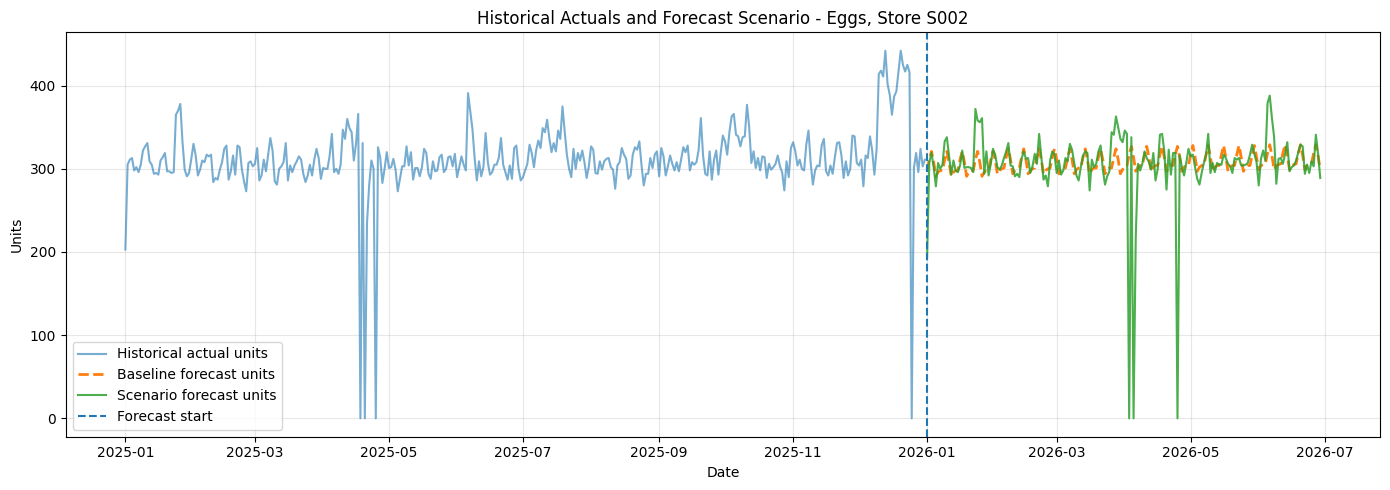

In [13]:
plot_store = "S002"
plot_product_id = "P003"

historical_plot_data = actuals[
    (actuals["store_id"] == plot_store)
    & (actuals["product_id"] == plot_product_id)
].copy()

forecast_plot_data = forecast_output[
    (forecast_output["store_id"] == plot_store)
    & (forecast_output["product_id"] == plot_product_id)
].copy()

product_label = products.loc[
    products["product_id"] == plot_product_id,
    "product_name"
].iloc[0]

plt.figure(figsize=(14, 5))

plt.plot(
    historical_plot_data["date"],
    historical_plot_data["actual_units"],
    label="Historical actual units",
    alpha=0.60
)

plt.plot(
    forecast_plot_data["date"],
    forecast_plot_data["baseline_forecast_units"],
    label="Baseline forecast units",
    linewidth=2,
    linestyle="--"
)

plt.plot(
    forecast_plot_data["date"],
    forecast_plot_data["scenario_forecast_units"],
    label="Scenario forecast units",
    alpha=0.85
)

plt.axvline(
    pd.Timestamp(FORECAST_START_DATE),
    linestyle="--",
    label="Forecast start"
)

plt.title(f"Historical Actuals and Forecast Scenario - {product_label}, Store {plot_store}")
plt.xlabel("Date")
plt.ylabel("Units")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 14. Export forecast outputs

The exported files are designed for Power BI and GitHub:

- `demand_forecast.csv`
- `scenario_events.csv`
- `calendar_extended.csv`

Use `calendar_extended.csv` as the Power BI date table because it covers both the 2025 historical actuals and the 2026 forecast period.


In [14]:
forecast_output.to_csv(DATA_DIR / "demand_forecast.csv", index=False)
scenario_events.to_csv(DATA_DIR / "scenario_events.csv", index=False)
calendar_extended.to_csv(DATA_DIR / "calendar_extended.csv", index=False)

print("Forecast output created successfully.")
print("Forecast date range:", forecast_output["date"].min().date(), "to", forecast_output["date"].max().date())
print("Rows:", len(forecast_output))
print("Stores:", forecast_output["store_id"].nunique())
print("Products:", forecast_output["product_id"].nunique())
print("Output files:")
print("- demand_forecast.csv")
print("- scenario_events.csv")
print("- calendar_extended.csv")


Forecast output created successfully.
Forecast date range: 2026-01-01 to 2026-06-29
Rows: 5400
Stores: 3
Products: 10
Output files:
- demand_forecast.csv
- scenario_events.csv
- calendar_extended.csv
